# Question 2: How do political attitudes and Human value priorities differ across generational cohorts in the Pre and post pandemic landscape?

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import statsmodels.api as sm

# Load the already cleaned and MRAT-corrected data
df = pd.read_csv('ess_final_analysis.csv')

#print(df.head())
#print(df.columns)

# The distribution of Generation in each ESS rounds.

In [38]:
# Check the distribution of generations across ESS rounds
counts = pd.crosstab(df['essround'], df['generation'])
print(counts)

generation  Boomers  Gen X  Gen Z  Millennials  Silent Gen
essround                                                  
9             14263  11124   2732         8530        5439
10            16298  14142   5440        11588        4555
11            13186  11690   4753         9514        3200


Essrond 9 is before COVID-19 (2018-2019)
Essrond 10 is during the Pandemic" Height (2020 -2022)
Essrond 11 is the post-pandemic landscape (2023 - 2024)

# The "Political Position" (The Average)

In [39]:
# Calculate the average political score for each generation
politics = df.groupby('generation')['lrscale'].mean().sort_values()
print(politics)

#Lower numbers (near 0) = Left-wing. Higher numbers (near 10) = Right-wing.

generation
Gen Z          4.908781
Millennials    4.977389
Boomers        4.998628
Gen X          5.093950
Silent Gen     5.248522
Name: lrscale, dtype: float64


Since the ESS lrscale goes from 0 (Left) to 10 (Right), with 5.0 being the exact middle:
- Gen Z (4.91): Is the only group clearly on the Left side of the "center line."
- Millennials & Boomers (4.97 - 4.99): Are sitting almost exactly on the fence (the middle).
- Gen X & Silent Gen (5.09 - 5.25): Are the groups leaning toward the Right side of the center.
This supports the theory that younger cohorts are more progressive, while older cohorts lean more toward conservative stability.

# The "Pandemic Shift" (The Change)

generation   Boomers     Gen X     Gen Z  Millennials  Silent Gen
essround                                                         
9           4.962350  5.059960  4.975110     5.014068    5.183857
10          4.992944  5.084712  4.814154     4.951588    5.245664
11          5.044896  5.137468  4.978961     4.975930    5.362500


Text(0, 0.5, 'Average Political Score (lrscale)')

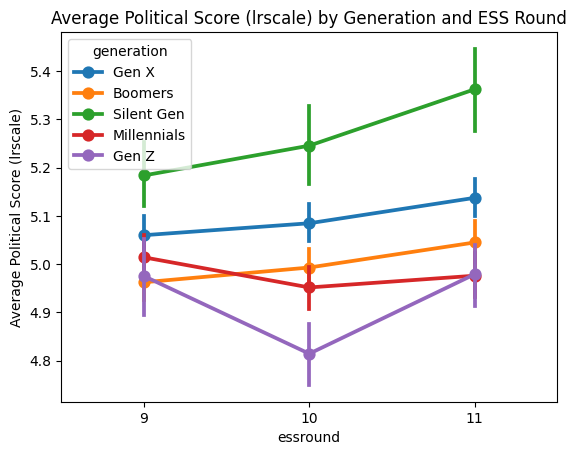

In [40]:
# Compare averages before ,Round 9 (2018), and after,to Round 11 (2024).
comparison = df.groupby(['essround', 'generation'])['lrscale'].mean().unstack()
print(comparison)

# Visual check
sns.pointplot(data=df, x='essround', y='lrscale', hue='generation')
plt.title('Average Political Score (lrscale) by Generation and ESS Round')
plt.ylabel('Average Political Score (lrscale)') 

Based on above table, we can see exactly how the "internal compass" of Europe moved through the crisis.

1. The "Gen Z" Paradox (Round 10)
    Gen Z in Round 10 (4.81). This is their lowest score (most Left-leaning).
    During the pandemic, young people shifted significantly toward the Left. This often happens during crises when younger cohorts look for more government support or social change.
    In Round 11 (4.98), We see the recound. They moved back to where they were in 2018. They didn't stay "extra" Left; they returned to their baseline.
    
2. The "Older Drift" (Boomers & Silent Gen)
    Unlike the younger groups, the older generations show a steady "climb" toward the Right (higher numbers).-
    - Boomers: Went from 4.96 -> 4.99 -> 5.04.
    - Silent Gen: Went from 5.18 -> 5.24 -> 5.36.
While the pandemic made Gen Z temporarily more progressive, it seems to have pushed older generations consistently toward more conservative positions. 
3. Millennials also like Gen Z, dipping down in the middle (Round 10).
4. The gap between the oldest and youngest is wider now (0.38) than it was in 2018 (0.21).

In [41]:
# Pick a few key values to compare
target_values = ['Universalism_centered', 'Tradition_centered', 'Security_centered']
compass = df.groupby('generation')[target_values].mean()
print(compass)
#Positive (+): This value is more important to that group than their other values.
#Negative (-): This value is less important to them.

             Universalism_centered  Tradition_centered  Security_centered
generation                                                               
Boomers                   0.643446            0.249867           0.553804
Gen X                     0.560890            0.006494           0.401021
Gen Z                     0.397068           -0.371962           0.157626
Millennials               0.491701           -0.214174           0.287018
Silent Gen                0.642957            0.462117           0.700370


In [42]:
# Check how 'Security' values changed for each generation over time
security_shift = df.groupby(['essround', 'generation'])['Security_centered'].mean().unstack()
print("Security Value Shift:")
print(security_shift)

Security Value Shift:
generation   Boomers     Gen X     Gen Z  Millennials  Silent Gen
essround                                                         
9           0.531134  0.398116  0.132125     0.245820    0.696976
10          0.531450  0.362185  0.127434     0.266118    0.675718
11          0.595791  0.433520  0.191459     0.339565    0.728880


In [43]:
# check how 'Universalism' values changed for each generation over time
universalism_shift = df.groupby(['essround', 'generation'])['Universalism_centered'].mean().unstack()
print("Universalism Value Shift:")
print(universalism_shift)

Universalism Value Shift:
generation   Boomers     Gen X     Gen Z  Millennials  Silent Gen
essround                                                         
9           0.673298  0.601640  0.455723     0.524556    0.657532
10          0.594120  0.515756  0.375076     0.449746    0.605533
11          0.649686  0.556656  0.376980     0.493236    0.652443


In [44]:
# Define our 10 MRAT-centered features 
schwartz_values = [
    'Universalism', 'Benevolence', 'Tradition', 'Security', 
    'Conformity', 'Self-Direction', 'Stimulation', 'Hedonism', 
    'Achievement', 'Power'
]
features = [f'{v}_centered' for v in schwartz_values]
print(f"Features for ALS: {features}")

# Create 'df_clean' by dropping NaNs of from 'df'
df_clean = df.dropna(subset=features + ['lrscale', 'generation']).copy()
print(f"Data cleaned. Rows remaining: {len(df_clean)}")


Features for ALS: ['Universalism_centered', 'Benevolence_centered', 'Tradition_centered', 'Security_centered', 'Conformity_centered', 'Self-Direction_centered', 'Stimulation_centered', 'Hedonism_centered', 'Achievement_centered', 'Power_centered']
Data cleaned. Rows remaining: 114985


In [45]:
# 4. The ALS Model (TruncatedSVD)
als = TruncatedSVD(n_components=2, random_state=42)
latent_factors = als.fit_transform(df_clean[features])

# Save the new coordinates back to the clean dataframe
df_clean['Factor_1'] = latent_factors[:, 0]
df_clean['Factor_2'] = latent_factors[:, 1]

print(f"✅ ALS Complete. Explained Variance: {als.explained_variance_ratio_.sum() * 100:.2f}%\n")

✅ ALS Complete. Explained Variance: 45.93%



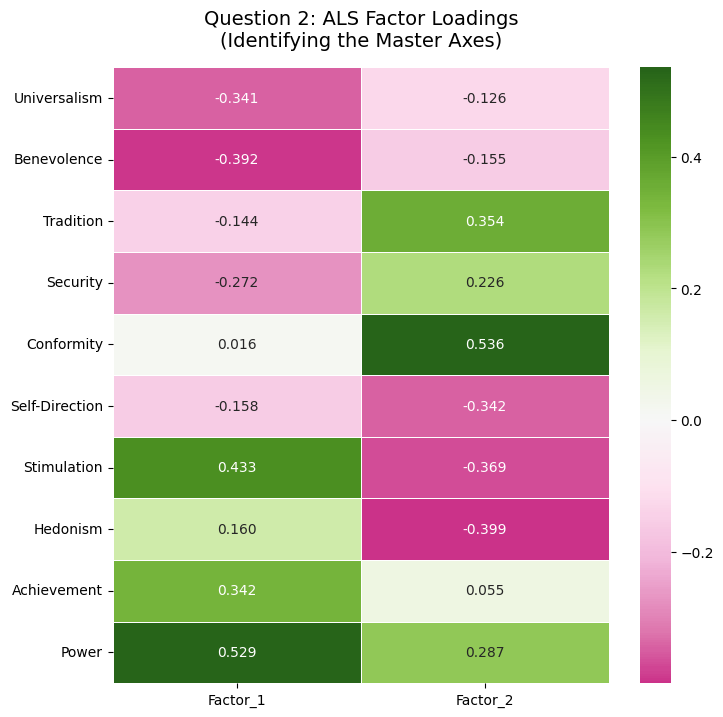

In [46]:
# 5. Plot the Loadings Heatmap
loadings = pd.DataFrame(
    als.components_.T, 
    columns=['Factor_1', 'Factor_2'], 
    index=schwartz_values
)

plt.figure(figsize=(8, 8))
sns.heatmap(loadings, annot=True, cmap='PiYG', center=0, fmt=".3f", linewidths=.5)
plt.title('Question 2: ALS Factor Loadings\n(Identifying the Master Axes)', fontsize=14, pad=15)
plt.show()